# Tutorial 3 — The sparsity confound (synthetic worst case)

This notebook walks through the *worst-case* scenario
`sparseNMF` is built to handle: two batches of cells with
the same biology but very different per-row sparsity
signatures. The synthetic data is constructed so that PCA
and vanilla NMF will *lock onto* the sparsity axis instead
of biology — and we'll see exactly when that happens.

All heavy lifting (data generator, model fits, figure
rendering) lives in `examples/sparsity_confound_demo.py` —
this notebook is the narrative wrapper. Cells should
execute in under a minute on CPU.

In [1]:
import sys, pathlib
for _p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
    if (_p / 'examples' / 'sparsity_confound_demo.py').exists():
        sys.path.insert(0, str(_p / 'examples'))
        break
else:
    raise RuntimeError('Could not locate the examples/ directory')
from sparsity_confound_demo import (
    make_sparsity_confound_data, fit_pca, fit_nmf, fit_sparse_nmf,
    umap_project, make_figure,
)
import numpy as np, time
from sklearn.metrics import silhouette_score
from pathlib import Path

## Construct the synthetic data

Three biological groups, each split into two *sparsity
batches* (low-nnz and high-nnz). Within each group the
underlying gene loadings are the same — only the
per-cell sparsity differs. So *biology* is identical
across batches but *nnz signatures* differ by ~10×.

In [2]:
X, groups, batches = make_sparsity_confound_data(seed=0)
nnz = np.asarray((X != 0).sum(axis=1)).ravel()
print(f'X shape={X.shape}  nnz={X.nnz:,}  density={X.nnz / (X.shape[0]*X.shape[1]):.2%}')
print(f'per-cell nnz: batch_low mean={nnz[batches == 0].mean():.0f}, '
      f'batch_high mean={nnz[batches == 1].mean():.0f}')

X shape=(600, 900)  nnz=107,794  density=19.96%
per-cell nnz: batch_low mean=32, batch_high mean=327


## Compare three factorizations

Each method produces a high-dim latent representation at
the same auto-sized `k`, then UMAP projects to 2-D. The
UMAP step is held constant, so any difference in the
embedding reflects the *factorization*, not the
projector.

In [3]:
seed = 0
k = int(np.clip(min(X.shape) // 8, 32, 1024))
print(f'shared latent dim k={k}')

embeddings, metrics = {}, {}
for name, fn in (('PCA', fit_pca), ('NMF', fit_nmf), ('sparseNMF', fit_sparse_nmf)):
    t0 = time.time()
    high = fn(X, seed, k)
    z = umap_project(high, seed)
    embeddings[name] = z
    sg = float(silhouette_score(z, groups))
    sb = float(silhouette_score(z, batches))
    metrics[name] = (sg, sb)
    print(f'  {name:>10s}: {time.time()-t0:5.1f}s  '
          f'silhouette(group)={sg:+.3f}  silhouette(batch)={sb:+.3f}')

shared latent dim k=75


         PCA:   5.1s  silhouette(group)=+0.354  silhouette(batch)=+0.307


         NMF:   1.8s  silhouette(group)=+0.603  silhouette(batch)=+0.085


/Users/bschilder/Desktop/sparseNMF/src/sparse_nmf/_core.py:339: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:767.)
  sparse_tensor = torch.sparse_coo_tensor(


   sparseNMF:   2.9s  silhouette(group)=+0.920  silhouette(batch)=+0.001


## Read the figure

**Row 1** — colored by biological group. The story we want
to see: 3 colors, 3 clean clusters.  
**Row 2** — colored by per-cell nnz. We do *not* want this
to look structured. If it does, the embedding has aligned
with the sparsity axis, which is exactly the failure mode
`sparseNMF`'s default `normalize_inputs=True` exists to
prevent.

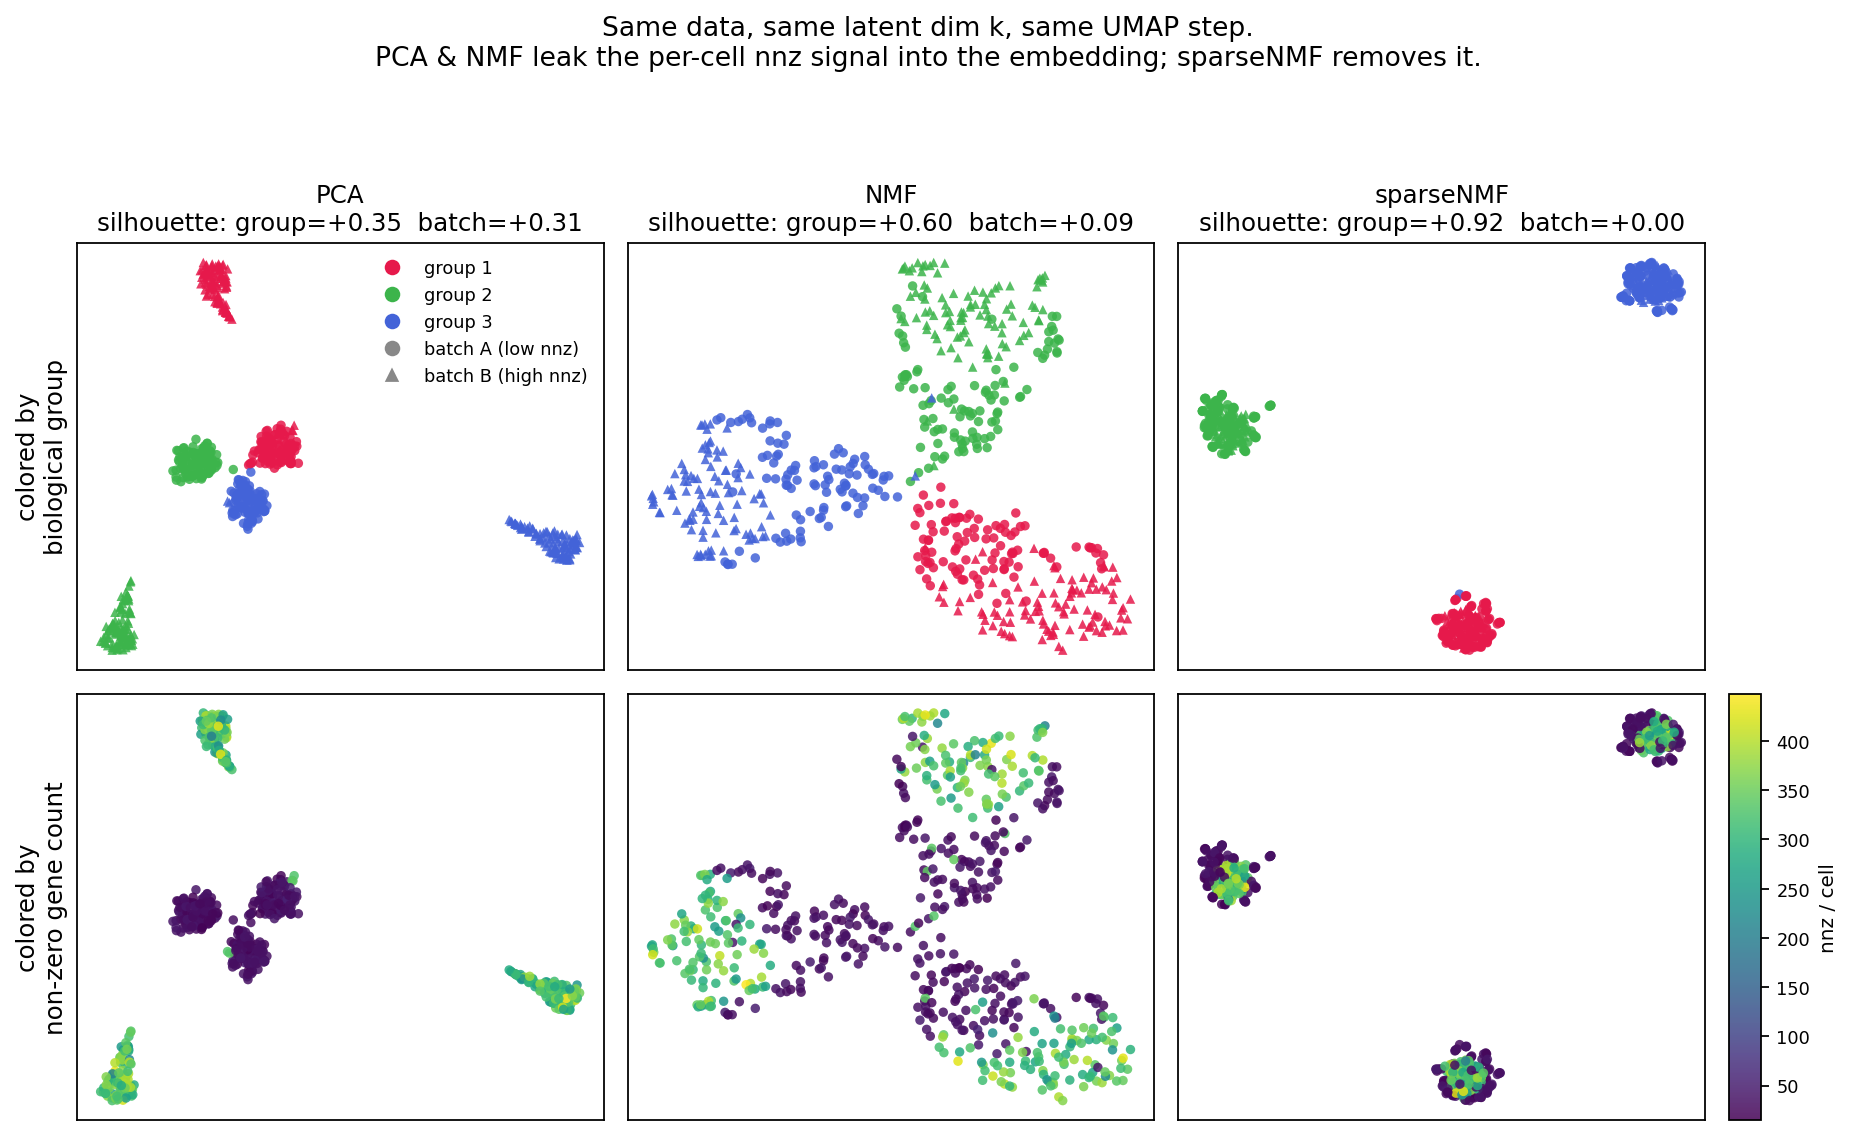

In [4]:
import tempfile
from IPython.display import Image
# Use a tempfile so this notebook doesn't overwrite the
# production figure at docs/_static/sparsity_confound_demo.png
# (that one is produced by `python examples/sparsity_confound_demo.py`).
_tmp = tempfile.NamedTemporaryFile(suffix='.png', delete=False)
_tmp.close()
make_figure(embeddings, metrics, groups, batches, nnz, Path(_tmp.name))
Image(filename=_tmp.name)

## Takeaway

PCA and vanilla NMF allocate their leading components to
*the per-cell magnitude axis* — variance dominated by the
per-row sparsity, not biology. UMAP then spreads cells
along that axis, scrambling group identity. `sparseNMF`
L2-normalizes each row before the multiplicative updates,
so the magnitude axis is gone before factorization
starts; the resulting embedding clusters by biology.

For a real-data version of the same story on cross-protocol
scRNA-seq, see Tutorial 4.